In [4]:
import pandas as pd

In [5]:
pd.read_csv(r'E:\4thYearProjectCoding\dataset\unified_dataset_new3.csv')

,patient_no,image_path,Patient_Age,Patient_Sex,WBC (x10^9/L),NEUT%,LYMP%,NLR,CRP (mg/L),PCT (ng/mL),Clinical_Observation,label
0,BLD02212,E:\4thYearProjectCoding\images\Corona Virus Di...,23,Female,3.56,64.91,8.55,7.59,114.38,0.26,"Symptoms include dry cough, headache, diarrhea...",Corona Virus Disease
1,BLD00785,E:\4thYearProjectCoding\images\Bacterial Pneum...,35,Female,15.82,78.54,10.32,7.61,156.21,6.65,Focal dense opacity with volume-preserved air ...,Bacterial Pneumonia
2,BLD01924,E:\4thYearProjectCoding\images\Tuberculosis\Tu...,38,Male,11.49,65.79,15.44,4.26,52.34,0.23,"ESR elevated, borderline leukocytosis, white c...",Tuberculosis
3,BLD07954,E:\4thYearProjectCoding\images\Tuberculosis\te...,20,Female,6.10,68.83,26.17,2.63,45.31,0.19,Mediastinal nodes are mildly prominent. white ...,Tuberculosis
4,BLD07299,E:\4thYearProjectCoding\images\Viral Pneumonia...,86,Male,3.00,56.08,10.88,5.15,23.56,0.23,"No segmental collapse, No suspicious cavitary ...",Viral Pneumonia
...,...,...,...,...,...,...,...,...,...,...,...,...
8895,BLD07596,E:\4thYearProjectCoding\images\Viral Pneumonia...,87,Female,6.66,50.68,29.93,1.69,30.66,0.13,Chest CT is almost clear except for diffuse br...,Viral Pneumonia
8896,BLD08849,E:\4thYearProjectCoding\images\Bacterial Pneum...,67,Female,20.13,75.08,6.74,11.14,60.43,1.27,"Patient describes malaise, sweats. Clinical da...",Bacterial Pneumonia
8897,BLD01728,E:\4thYearProjectCoding\images\Tuberculosis\te...,26,Male,13.35,72.70,7.50,9.69,42.92,0.23,"Clinical history notes hemoptysis, reduced app...",Tuberculosis
8898,BLD01546,E:\4thYearProjectCoding\images\Corona Virus Di...,63,Male,8.07,74.85,22.15,3.38,57.62,0.16,Peripheral ground-glass opacities in the diffu...,Corona Virus Disease


In [6]:
df = pd.read_csv(r'E:\4thYearProjectCoding\dataset\unified_dataset_new3.csv')

In [7]:
df.dtypes

patient_no                  str
image_path                  str
Patient_Age               int64
Patient_Sex                 str
WBC (x10^9/L)           float64
NEUT%                   float64
LYMP%                   float64
NLR                     float64
CRP (mg/L)              float64
PCT (ng/mL)             float64
Clinical_Observation        str
label                       str
dtype: object

**Univariate Analysis**

In [8]:
numeric_cols = ['Patient_Age', 'WBC (x10^9/L)', 'NEUT%', 'LYMP%', 'NLR', 'CRP (mg/L)', 'PCT (ng/mL)']

summary = df[numeric_cols].describe().T
summary['median'] = df[numeric_cols].median()
summary['IQR'] = summary['75%'] - summary['25%']
summary['skewness'] = df[numeric_cols].skew()
print("Numeric Summary Statistics:\n")
summary

Numeric Summary Statistics:



,count,mean,std,min,25%,50%,75%,max,median,IQR,skewness
Patient_Age,8900.0,47.146404,26.793287,1.00,25.000,46.000,70.0000,95.00,46.000,45.0000,0.046601
WBC (x10^9/L),8900.0,8.884233,4.768717,2.00,5.830,7.480,10.3925,35.00,7.480,4.5625,1.590157
NEUT%,8900.0,67.747762,12.557954,30.90,58.200,67.935,77.7225,95.15,67.935,19.5225,-0.126597
LYMP%,8900.0,20.252038,10.614281,1.96,11.220,19.130,28.9525,55.00,19.130,17.7325,0.282425
NLR,8900.0,5.563847,5.945000,0.67,2.000,3.610,6.8400,48.49,3.610,4.8400,3.394721
CRP (mg/L),8900.0,58.419458,57.308061,0.10,8.745,44.430,85.4950,349.04,44.430,76.7500,1.356315
PCT (ng/mL),8900.0,0.782161,1.798107,0.01,0.040,0.130,0.3225,14.51,0.130,0.2825,3.226717


In [9]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

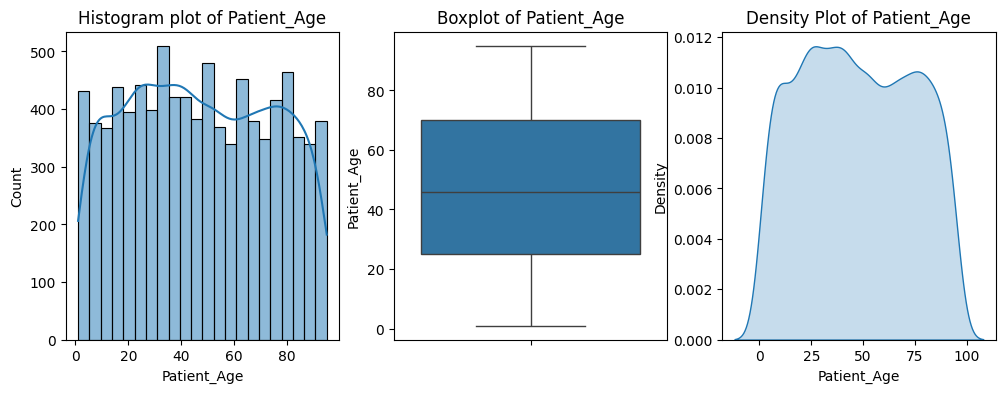

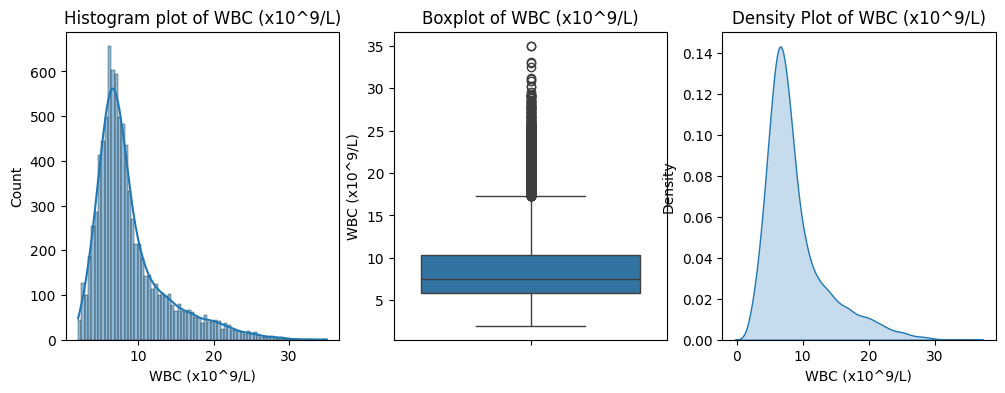

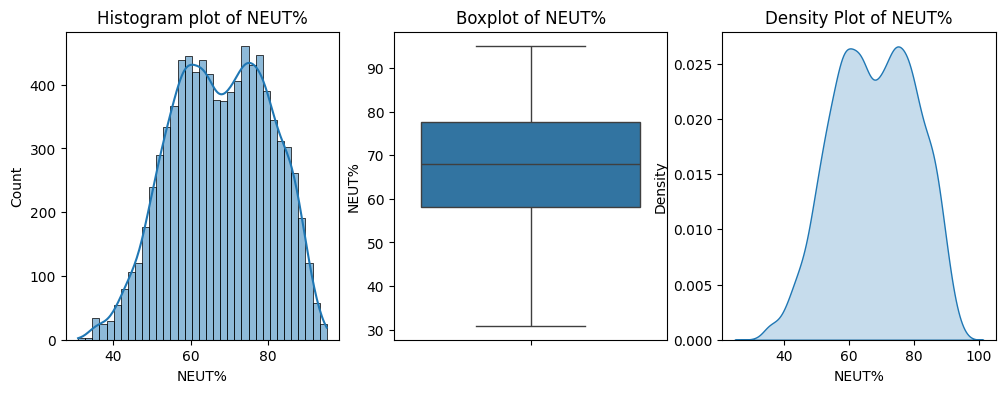

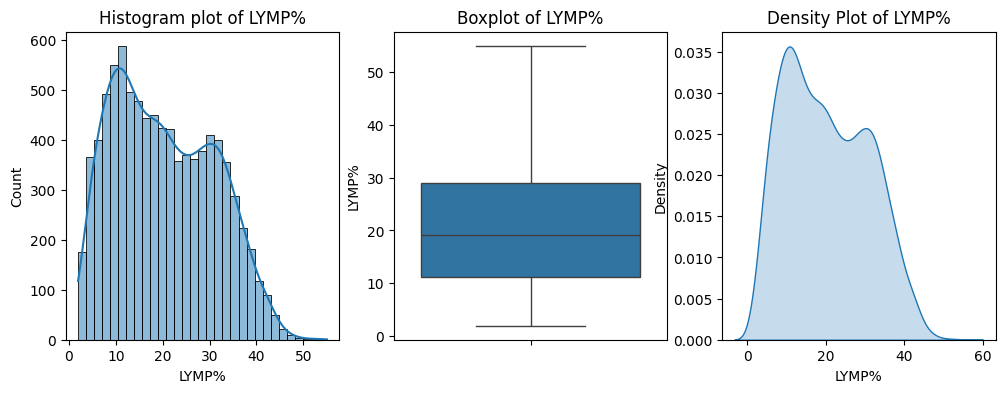

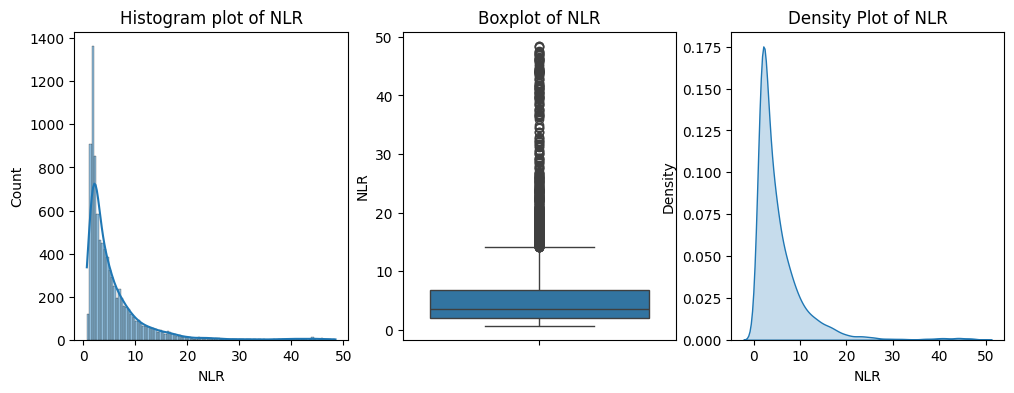

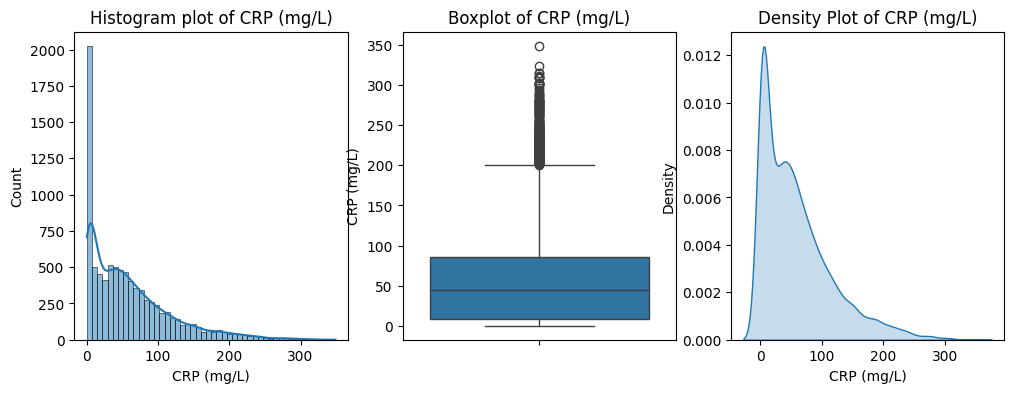

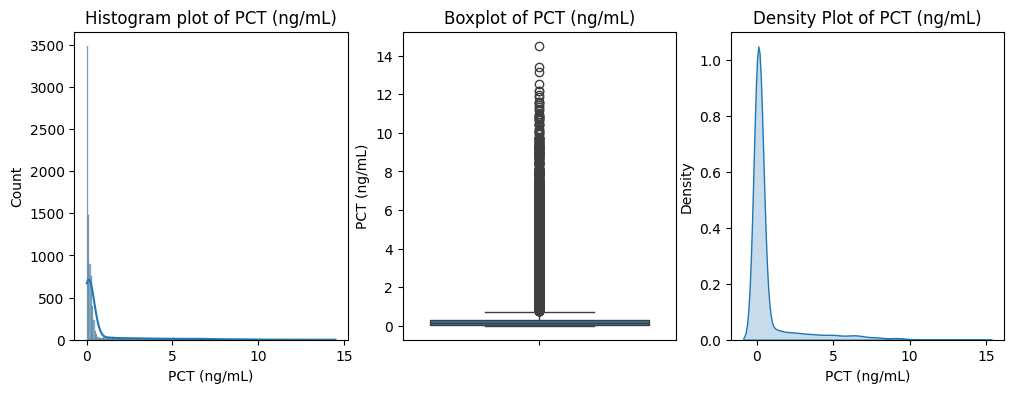

In [11]:
# Histogram, boxplot, density plot for numerical columns
for col in numeric_cols:
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    sns.histplot(df[col], kde = True)
    plt.title(f'Histogram plot of {col}')

    plt.subplot(1, 3, 2)
    sns.boxplot(y = df[col])
    plt.title(f'Boxplot of {col}')

    plt.subplot(1, 3, 3)
    sns.kdeplot(df[col], fill = True)
    plt.title(f'Density Plot of {col}')


 Frequency counts for Patient_Sex:
 Patient_Sex
Female    4514
Male      4386
Name: count, dtype: int64


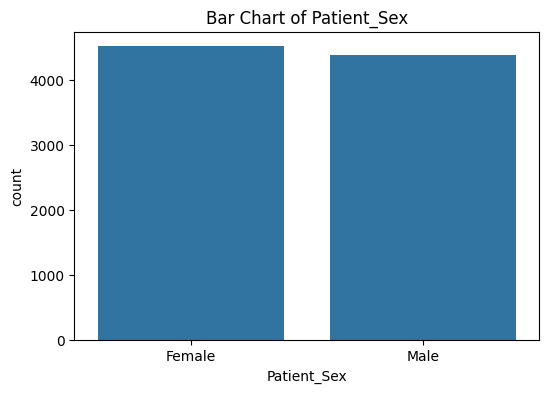

C:\Users\SOUPTIK DEY\AppData\Local\Temp\ipykernel_2280\476535329.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Age_Group', palette='viridis')


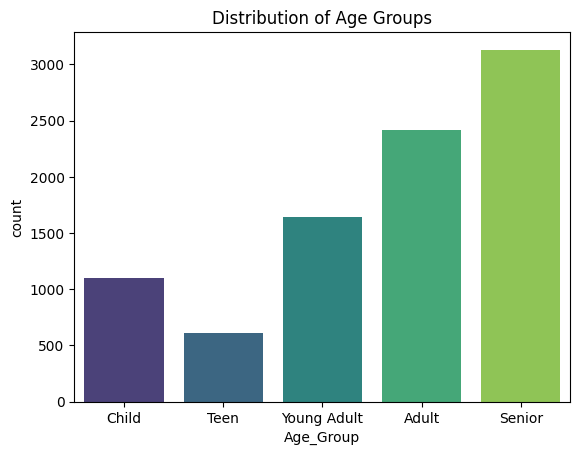

In [12]:
# Frequency count for categorical columns

cat_cols = ['Patient_Sex']

for index, col in enumerate(cat_cols):
    print(f"\n Frequency counts for {col}:\n", df[col].value_counts())
    plt.figure(figsize = (6, 4))
    sns.countplot(x=col, data=df, order=df[col].value_counts().index)
    plt.title(f'Bar Chart of {col}')
    plt.show()

# Define the edges: 0-12, 13-19, 20-35, 36-60, 60+
bins = [0, 12, 19, 35, 60, 100]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']

# This creates a new column called 'Age_Group'
df['Age_Group'] = pd.cut(df['Patient_Age'], bins=bins, labels=labels)

sns.countplot(data=df, x='Age_Group', palette='viridis')
plt.title('Distribution of Age Groups')
plt.show()

# sns.boxplot(data=df, x='Age_Group', y='some_other_column')
# plt.show()


In [13]:
print(df.columns.tolist())

['patient_no', 'image_path', 'Patient_Age', 'Patient_Sex', 'WBC (x10^9/L)', 'NEUT%', 'LYMP%', 'NLR', 'CRP (mg/L)', 'PCT (ng/mL)', 'Clinical_Observation', 'label', 'Age_Group']


**Bi-variate Analysis**

In [14]:
# corr = df.corr()

# plt.figure(figsize=(5, 4))
# sns.heatmap(corr, anno=True, cmap='coolwarm', fmt='.2f')
# plt.title('Correlation Heatmap')
# plt.show()

# # Pairwise scatter plots + regression line
# sns.pairplot(df, kind='reg', diag_king='kde', corner=True, plot_kws={'line_kws':{'color':'red'}})
# plt.suptitle('Scatter and Regression LInes Between Numeric Variables', y=1.02)
# plt.show()

In [15]:
# Shows how many people in each Age_Group are in each Department
ct = pd.crosstab(df['Patient_Age'], df['label'])
print(ct)

label        Bacterial Pneumonia  Corona Virus Disease  Normal  Tuberculosis  \
Patient_Age                                                                    
1                             38                    12      11             0   
2                             26                     6      22             0   
3                             26                     8       8             0   
4                             28                    12      26             0   
5                             30                    11      14             1   
...                          ...                   ...     ...           ...   
91                            21                    11      15            12   
92                            12                    11      20             6   
93                            19                    14      21             5   
94                            14                     8      20             7   
95                            19        

C:\Users\SOUPTIK DEY\AppData\Local\Temp\ipykernel_2280\2964514867.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='WBC (x10^9/L)', palette='Set2')


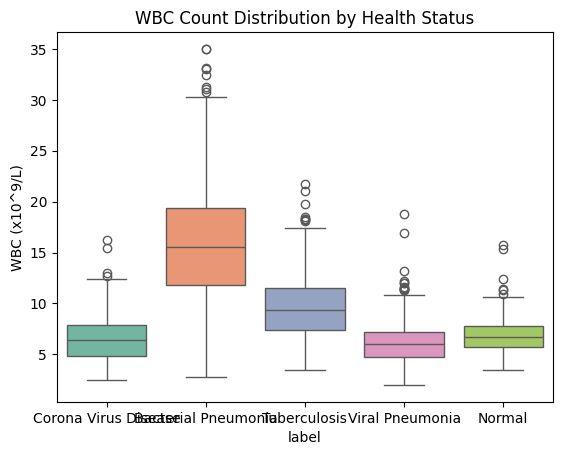

C:\Users\SOUPTIK DEY\AppData\Local\Temp\ipykernel_2280\2964514867.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='NEUT%', palette='Set2')


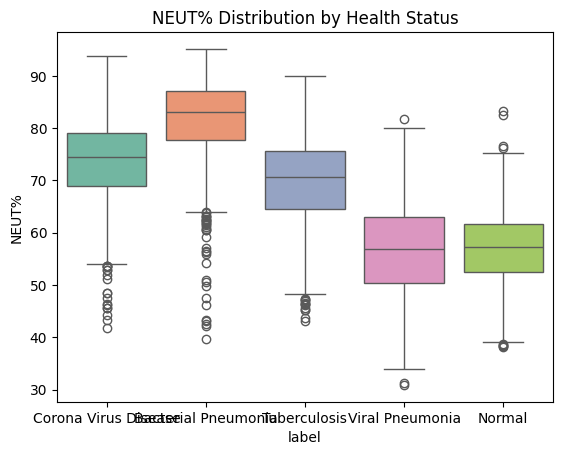

C:\Users\SOUPTIK DEY\AppData\Local\Temp\ipykernel_2280\2964514867.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='LYMP%', palette='Set2')


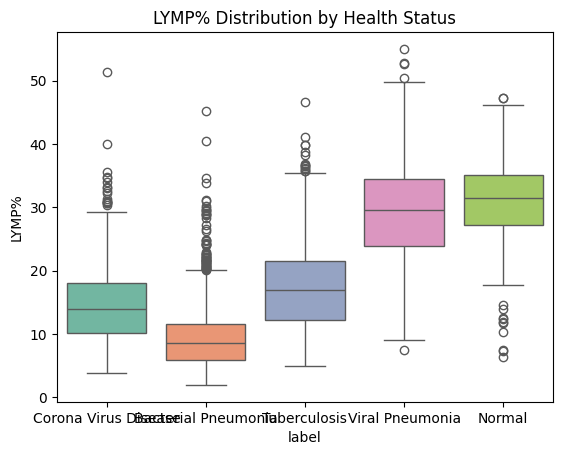

C:\Users\SOUPTIK DEY\AppData\Local\Temp\ipykernel_2280\2964514867.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='NLR', palette='Set2')


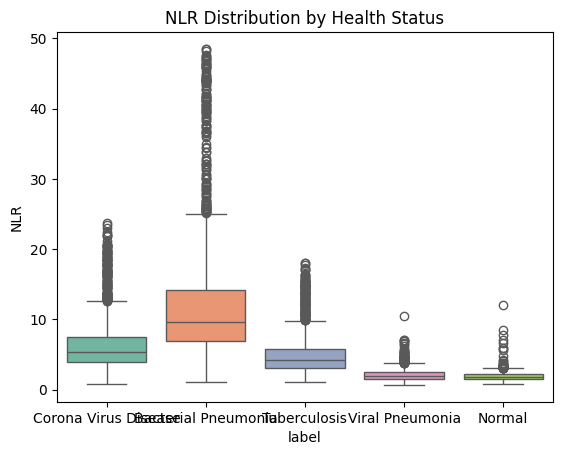

C:\Users\SOUPTIK DEY\AppData\Local\Temp\ipykernel_2280\2964514867.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='CRP (mg/L)', palette='Set2')


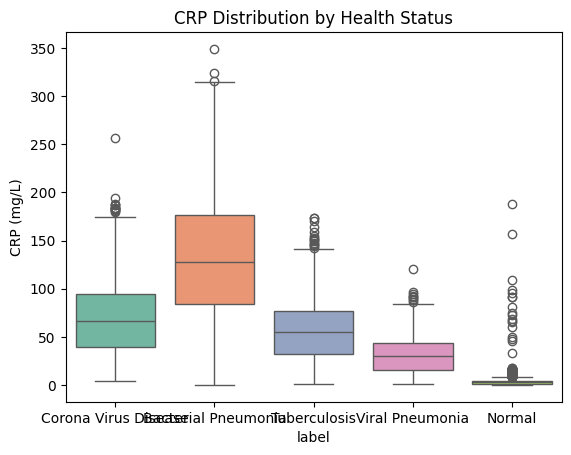

C:\Users\SOUPTIK DEY\AppData\Local\Temp\ipykernel_2280\2964514867.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='PCT (ng/mL)', palette='Set2')


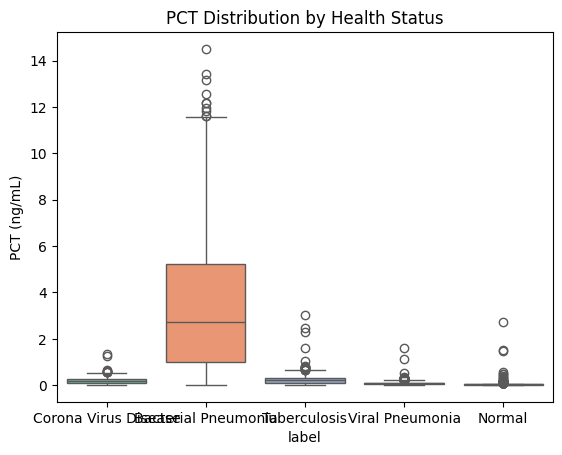

In [16]:
sns.boxplot(data=df, x='label', y='WBC (x10^9/L)', palette='Set2')
plt.title('WBC Count Distribution by Health Status')
plt.show()

sns.boxplot(data=df, x='label', y='NEUT%', palette='Set2')
plt.title(r'NEUT% Distribution by Health Status')
plt.show()

sns.boxplot(data=df, x='label', y='LYMP%', palette='Set2')
plt.title(r'LYMP% Distribution by Health Status')
plt.show()

sns.boxplot(data=df, x='label', y='NLR', palette='Set2')
plt.title(r'NLR Distribution by Health Status')
plt.show()

sns.boxplot(data=df, x='label', y='CRP (mg/L)', palette='Set2')
plt.title(r'CRP Distribution by Health Status')
plt.show()

sns.boxplot(data=df, x='label', y='PCT (ng/mL)', palette='Set2')
plt.title(r'PCT Distribution by Health Status')
plt.show()

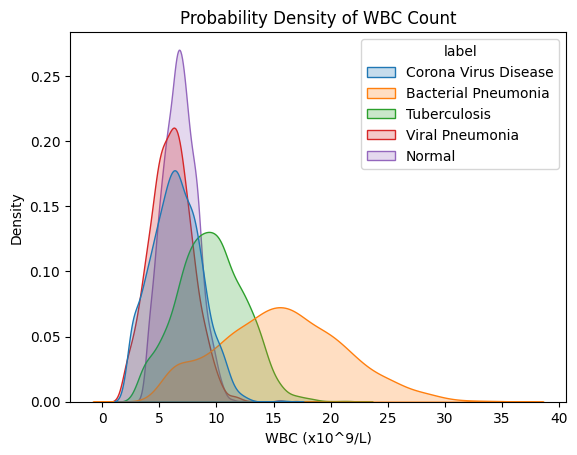

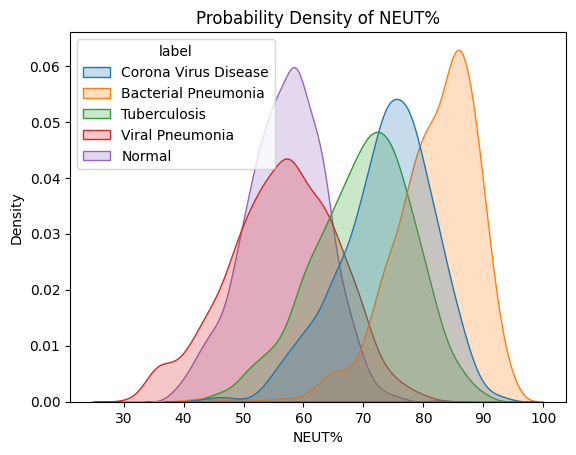

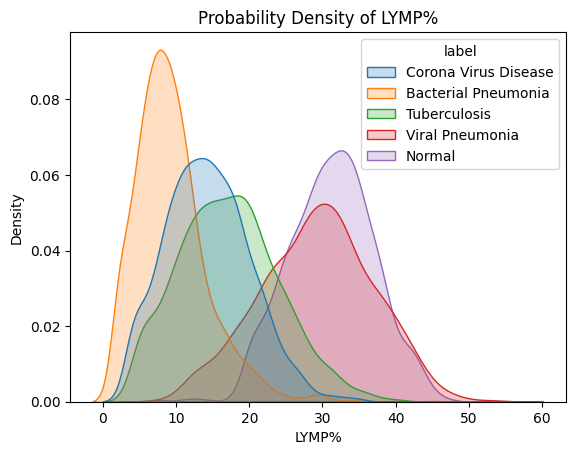

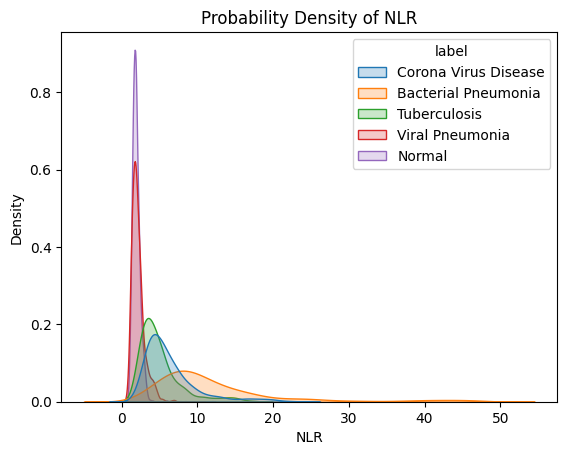

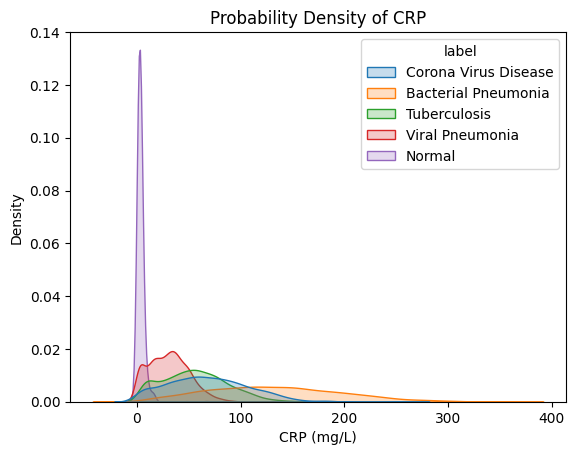

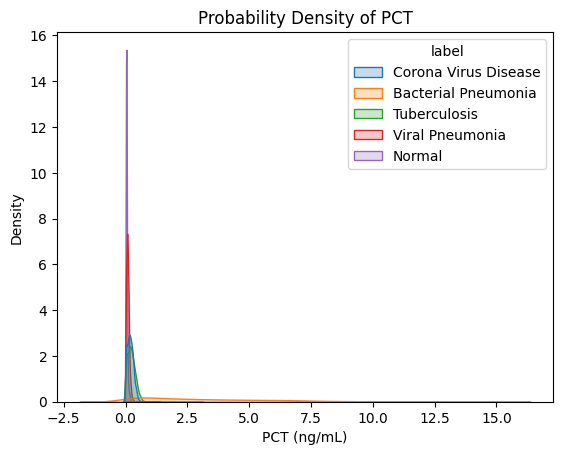

In [17]:
# 'hue' splits the single 'wbc_count' into colored curves based on the label
sns.kdeplot(data=df, x='WBC (x10^9/L)', hue='label', fill=True, common_norm=False)
plt.title('Probability Density of WBC Count')
plt.show()

sns.kdeplot(data=df, x='NEUT%', hue='label', fill=True, common_norm=False)
plt.title('Probability Density of NEUT%')
plt.show()

sns.kdeplot(data=df, x='LYMP%', hue='label', fill=True, common_norm=False)
plt.title('Probability Density of LYMP%')
plt.show()

sns.kdeplot(data=df, x='NLR', hue='label', fill=True, common_norm=False)
plt.title('Probability Density of NLR')
plt.show()

sns.kdeplot(data=df, x='CRP (mg/L)', hue='label', fill=True, common_norm=False)
plt.title('Probability Density of CRP')
plt.show()

sns.kdeplot(data=df, x='PCT (ng/mL)', hue='label', fill=True, common_norm=False)
plt.title('Probability Density of PCT')
plt.show()

In [18]:
df.dtypes

patient_no                   str
image_path                   str
Patient_Age                int64
Patient_Sex                  str
WBC (x10^9/L)            float64
NEUT%                    float64
LYMP%                    float64
NLR                      float64
CRP (mg/L)               float64
PCT (ng/mL)              float64
Clinical_Observation         str
label                        str
Age_Group               category
dtype: object